# Session 11: Diagnostics, PPC & Predictive Model Comparison

**Bayesian Analysis of Empirical Data (2026)**  
*Author: Irina Knyazeva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iknyazeva/bayes-cogsci-book/blob/main/notebooks/colab/11_diagnostics_ppc_model_comparison.ipynb)

### Obligatory Graded Assessment: Task 3 Vertical Slice
In this laboratory, students navigate the complete **Model Selection Ladder**: validating the MCMC computational diagnostic gate, running targeted posterior predictive checks (PPC), and executing out-of-sample predictive model comparison via Pareto-smoothed importance sampling leave-one-out cross-validation (**PSIS-LOO**).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
rng = np.random.default_rng(2026)

# Synthetic replica of KidIQ dataset (N = 434)
N = 434
mom_hs = rng.binomial(1, 0.78, size=N)
mom_iq = rng.normal(100, 15, size=N)
mom_iq_c = mom_iq - 100.0
mu_true = 82 + 0.56 * mom_iq_c + 5.5 * mom_hs - 0.48 * mom_iq_c * mom_hs
kid_score = rng.normal(mu_true, 18)

df = pd.DataFrame({"kid_score": kid_score, "mom_iq_c": mom_iq_c, "mom_hs": mom_hs})
df.head()

,kid_score,mom_iq_c,mom_hs
0,70.181200,7.371243,1
1,121.830958,10.219754,1
2,119.190362,7.994288,1
3,79.073183,11.265698,1
4,66.877069,-10.335592,1


## 1. Fitting Candidate Models: Additive vs. Interaction

In [2]:
# Candidate 1: Additive Model
with pm.Model() as mod_additive:
    alpha = pm.Normal("alpha", mu=80.0, sigma=15.0)
    beta_iq = pm.Normal("beta_iq", mu=0.5, sigma=0.5)
    beta_hs = pm.Normal("beta_hs", mu=5.0, sigma=10.0)
    sigma = pm.HalfNormal("sigma", sigma=20.0)
    
    mu = alpha + beta_iq * df["mom_iq_c"].values + beta_hs * df["mom_hs"].values
    y_obs = pm.Normal("kid_score", mu=mu, sigma=sigma, observed=df["kid_score"].values)
    
    idata_add = pm.sample(draws=1000, tune=1000, chains=4, random_seed=2026, return_inferencedata=True, idata_kwargs={"log_likelihood": True})

# Candidate 2: Interaction Model
with pm.Model() as mod_inter:
    alpha = pm.Normal("alpha", mu=80.0, sigma=15.0)
    beta_iq = pm.Normal("beta_iq", mu=0.5, sigma=0.5)
    beta_hs = pm.Normal("beta_hs", mu=5.0, sigma=10.0)
    beta_inter = pm.Normal("beta_inter", mu=0.0, sigma=0.5)
    sigma = pm.HalfNormal("sigma", sigma=20.0)
    
    mu = alpha + beta_iq * df["mom_iq_c"].values + beta_hs * df["mom_hs"].values + beta_inter * (df["mom_iq_c"].values * df["mom_hs"].values)
    y_obs = pm.Normal("kid_score", mu=mu, sigma=sigma, observed=df["kid_score"].values)
    
    idata_inter = pm.sample(draws=1000, tune=1000, chains=4, random_seed=2026, return_inferencedata=True, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta_iq, beta_hs, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta_iq, beta_hs, beta_inter, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


## 2. Passing the Computational Gate & PSIS-LOO Comparison

Additive Diagnostics (max R-hat, min ESS):
Max R-hat: 1.000, Min ESS Bulk: 2070



=== Model Comparison Table (PSIS-LOO) ===
                elpd_loo     p_loo  elpd_diff         se        weight
Interaction -1862.992953  4.684233    0.00000  14.824434  1.000000e+00
Additive    -1866.564874  4.042934    3.57192  14.895593  1.498801e-15


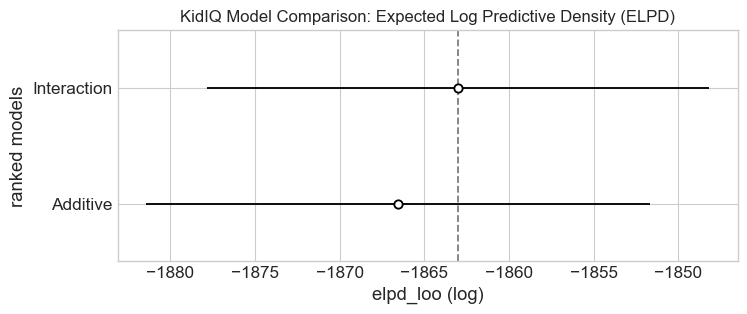

In [3]:
# Gate 1: Check R-hat and ESS
diag_add = az.summary(idata_add, var_names=["alpha", "beta_iq", "beta_hs", "sigma"])
print("Additive Diagnostics (max R-hat, min ESS):")
print(f"Max R-hat: {diag_add['r_hat'].max():.3f}, Min ESS Bulk: {diag_add['ess_bulk'].min():.0f}")

# Gate 2: Formal Model Comparison via PSIS-LOO
comp_df = az.compare({"Additive": idata_add, "Interaction": idata_inter}, ic="loo")
print("\n=== Model Comparison Table (PSIS-LOO) ===")
print(comp_df[["elpd_loo", "p_loo", "elpd_diff", "se", "weight"]])

# Plot comparison with uncertainty bars
az.plot_compare(comp_df, figsize=(8, 3))
plt.title("KidIQ Model Comparison: Expected Log Predictive Density (ELPD)")
plt.show()